- India −30%: mean +0.23%, median 0.0% - muted, threshold-driven response, 67/95 products affected.
- Local +20%: mean -2.3%, median -0.22% - modest downward pressure, most coherent/expected direction, 64/95 affected.
- China → 0: mean -1.98%, median 0.0% - narrow reach (16/95 products), consistent with China being a minor source overall.

# General Imports

In [1]:
import lightgbm as lgb
import pandas as pd
import numpy as np
import json
from features import load_clean_data, get_src_cols, compute_risk 
from scenario_engine004 import run_product_scenario, build_scenario_baseline

cat_cols = ['product_name', 'category', 'unit']
import inspect
from scenario_engine004 import run_product_scenario
# print(inspect.getsource(run_product_scenario))



## Predictions

In [2]:
pd.set_option('display.max_rows', None)        # show all rows
pd.set_option('display.max_columns', None)     # show all columns
# pd.set_option('display.expand_frame_repr', False)  # don't wrap with ...
# pd.set_option('display.max_colwidth', None)    # show full column content

# ---- load everything once ----
d = load_clean_data()
src_cols = get_src_cols(d)
imp_cols = [c for c in ['india', 'china', 'bhutan'] if c in src_cols]

feature_cols = (
    ['product_name', 'category', 'unit', 'm_sin', 'm_cos', 'n_sources',
     'herfindahl', 'import_share', 'domestic_share', 'n_months_present',
     'india_share', 'china_share', 'bhutan_share', 'avg_price_lag1']
    + src_cols
)

booster = lgb.Booster(model_file='../models/price_surrogate_final.txt')
product_vol_stats = pd.read_parquet('../data/processed/product_volume_stats.parquet').reset_index()
with open('../data/processed/risk_scaling_ref.json') as f:
    scaling_ref = json.load(f)

# ---- test a mix: heavy India sourcing, sparse India sourcing, zero India sourcing ----
test_products = ['Orange_Sweet', 'Apple', 'Pear', 'Potato', 'Sugarcane']

print(f"{'Product':<15} {'Status':<20} {'Coverage':<30} {'BaselinePrice':>13} {'ShockedPrice':>13} {'Delta%':>8} {'Risk':>8}")
print("-" * 115)

rows = []
for p in test_products:
    result = run_product_scenario(
        d, p, {'india': 0.7}, booster, feature_cols,
        cat_cols, product_vol_stats, scaling_ref, src_cols, imp_cols
    )
    rows.append(result)

results_df = pd.DataFrame(rows)
results_df.head(3)
    

Product         Status               Coverage                       BaselinePrice  ShockedPrice   Delta%     Risk
-------------------------------------------------------------------------------------------------------------------


,product_name,status,baseline_month,coverage,confidence,baseline_price,model_baseline_price,predicted_price,price_delta_pct,predicted_volume,baseline_risk,baseline_risk_score,risk_score,risk
0,Orange_Sweet,ok,month 10,india: sourced in 7/10 months,india: reliable,110.0,110.091692,109.264051,-0.751774,2975.000000,Low,0.186645,0.639984,Medium
1,Apple,ok,month 10,india: sourced in 6/10 months,india: reliable,266.3,254.204475,255.386840,0.465124,413769.316667,Medium,0.580614,0.445999,Medium
2,Pear,ok,month 10,india: sourced in 6/9 months,india: reliable,205.0,204.967666,204.554070,-0.201786,24768.666667,Medium,0.475800,0.475800,Medium


## INDIA -30% supply (Hypothetical)
All products results in df (Externally not Saved)

In [ ]:
# India -30%, all products
# from scenario_runner import run_scenario_report  -> old. moved to scenario_engine004.py
from scenario_engine004 import run_scenario_report

# results_india, summary_india = run_scenario_report(
#     d, {'india': 0.7}, products=None,
#     price_booster=booster, feature_cols=feature_cols, cat_cols=cat_cols,
#     product_vol_stats=product_vol_stats, scaling_ref=scaling_ref,
#     src_cols=src_cols, imp_cols=imp_cols
# )
# results_india.head()

In [4]:
results_india, summary_india = run_scenario_report(
    d, {'india': 0.7}, products=None,
    price_booster=booster, feature_cols=feature_cols, cat_cols=cat_cols,
    product_vol_stats=product_vol_stats, scaling_ref=scaling_ref,
    src_cols=src_cols, imp_cols=imp_cols
)
print(summary_india)

{'n_products_affected': 67, 'n_products_na': np.int64(28), 'mean_price_delta_pct': np.float64(0.2326621633350768), 'median_price_delta_pct': np.float64(0.0), 'n_products_risk_increased': np.int64(7)}


## Local +20% 

In [5]:
# Local +20%, all products
results_local, summary_local = run_scenario_report(
    d, {'local': 1.2}, products=None,
    price_booster=booster, feature_cols=feature_cols, cat_cols=cat_cols,
    product_vol_stats=product_vol_stats, scaling_ref=scaling_ref,
    src_cols=src_cols, imp_cols=imp_cols
)
results_local.tail(2)


,product_name,status,baseline_month,coverage,confidence,baseline_price,model_baseline_price,predicted_price,price_delta_pct,predicted_volume,baseline_risk,baseline_risk_score,risk_score,risk
93,Watermelon,ok,month 10,local: sourced in 1/10 months,local: single-observation,41.63,46.316152,46.316152,0.000000,1757571.00,Medium,0.377237,0.377216,Medium
94,Yam,ok,month 10,local: sourced in 8/8 months,local: reliable,110.00,110.033978,96.736268,-12.085094,25076.25,Medium,0.370514,0.370514,Medium


In [ ]:
print(summary_local)

{'n_products_affected': 64, 'n_products_na': np.int64(31), 'mean_price_delta_pct': np.float64(-2.307497869498728), 'median_price_delta_pct': np.float64(-0.21840513458526445), 'n_products_risk_increased': np.int64(7)}


In [ ]:
ok_local = results_local[results_local['status']=='ok'].copy()
print(ok_local.sort_values('price_delta_pct').head(5)[['product_name','price_delta_pct']])
print(ok_local.sort_values('price_delta_pct', ascending=False).head(5)[['product_name','price_delta_pct']])

    product_name  price_delta_pct
37    Green_Peas       -14.954569
40       Gundruk       -14.154057
87    Sword_Bean       -12.779433
94           Yam       -12.085094
9   Banana_Green       -10.692506
    product_name  price_delta_pct
21        Carrot         4.931836
82        Squash         2.627114
13  Bitter_Gourd         1.893934
23  Chilly_Green         1.466206
16  Brinjal_Long         1.262531


In [ ]:
def diagnose_product(d, product, price_booster, feature_cols, cat_cols, src_cols, imp_cols):
    baseline_row, month = build_scenario_baseline(d, product)
    X_base = baseline_row[feature_cols].copy()
    for c in cat_cols:
        X_base[c] = X_base[c].astype('category')
    pred_baseline = np.expm1(price_booster.predict(X_base))[0]
    actual_baseline = baseline_row['avg_price'].values[0]
    print(f"{product}: actual={actual_baseline:.2f}  model's own unshocked prediction={pred_baseline:.2f}  gap={pred_baseline-actual_baseline:.2f}")

for p in ['Sweet_Potato', 'Potato', 'Mango', 'Avocado', 'Grapes']:
    diagnose_product(d, p, booster, feature_cols, cat_cols, src_cols, imp_cols)

Sweet_Potato: actual=30.00  model's own unshocked prediction=94.70  gap=64.70
Potato: actual=32.84  model's own unshocked prediction=86.63  gap=53.79
Mango: actual=198.26  model's own unshocked prediction=315.17  gap=116.91
Avocado: actual=757.61  model's own unshocked prediction=392.04  gap=-365.57
Grapes: actual=450.00  model's own unshocked prediction=253.40  gap=-196.60


## Chaina  -> 0

In [7]:
results_china, summary_china = run_scenario_report(
    d, {'china': 0.0}, products=None,
    price_booster=booster, feature_cols=feature_cols, cat_cols=cat_cols,
    product_vol_stats=product_vol_stats, scaling_ref=scaling_ref,
    src_cols=src_cols, imp_cols=imp_cols
)
print(summary_china)

{'n_products_affected': 16, 'n_products_na': np.int64(79), 'mean_price_delta_pct': np.float64(-1.9837965642457878), 'median_price_delta_pct': np.float64(0.0), 'n_products_risk_increased': np.int64(0)}


In [ ]:
# results_india.to_csv('../outputs/scenario_india_minus30.csv', index=False)
# results_local.to_csv('../outputs/scenario_local_plus20.csv', index=False)
# results_china.to_csv('../outputs/scenario_china_zero.csv', index=False)

## India + Local (combined)

In [9]:
results_combined, summary_combined = run_scenario_report(
    d, {'india': 0.7, 'local': 1.2}, products=None,
    price_booster=booster, feature_cols=feature_cols, cat_cols=cat_cols,
    product_vol_stats=product_vol_stats, scaling_ref=scaling_ref,
    src_cols=src_cols, imp_cols=imp_cols
)
print(summary_combined)

ok_combined = results_combined[results_combined['status']=='ok'].copy()
print(ok_combined.sort_values('price_delta_pct').head(5)[['product_name','price_delta_pct']])
print(ok_combined.sort_values('price_delta_pct', ascending=False).head(5)[['product_name','price_delta_pct']])

# results_combined.to_csv('../outputs/scenario_india_minus30_local_plus20.csv', index=False)

{'n_products_affected': 84, 'n_products_na': np.int64(11), 'mean_price_delta_pct': np.float64(-1.4428028208348682), 'median_price_delta_pct': np.float64(0.0), 'n_products_risk_increased': np.int64(10)}
    product_name  price_delta_pct
40       Gundruk       -16.797503
94           Yam       -12.765052
37    Green_Peas       -11.738683
85  Sweet_Pepper       -11.505725
87    Sword_Bean       -10.163730
     product_name  price_delta_pct
19        Cabbage         6.531084
72   Radish_White         5.073002
13   Bitter_Gourd         4.977102
62  Pointed_Gourd         4.809755
49    Mango_Green         4.233275


 1. scenario_sensitivity_ranking ----

In [ ]:
import matplotlib.pyplot as plt

ok = results_india[results_india['status']=='ok'].copy()
ok = ok.sort_values('price_delta_pct')

confidence_colors = {'reliable': '#2c7fb8', 'low-confidence': '#fdae61', 'single-observation': '#d7191c'}
ok['conf_simple'] = ok['confidence'].str.extract(r'india: (\w[\w-]*)')
colors = ok['conf_simple'].map(confidence_colors).fillna('#999999')

fig, ax = plt.subplots(figsize=(9, max(8, len(ok)*0.22)))
ax.barh(ok['product_name'], ok['price_delta_pct'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Predicted price change (%) under India −30% shock')
ax.set_title('Product sensitivity to an India supply cut')

handles = [plt.Rectangle((0,0),1,1, color=c) for c in confidence_colors.values()]
ax.legend(handles, confidence_colors.keys(), title='Coverage confidence', loc='lower right')
plt.tight_layout()
# plt.savefig('../outputs/images/scenario_sensitivity_ranking.png', dpi=150)
plt.show()

Scenario Vs Import Share

In [ ]:
# ---- 2. scenario_price_vs_import_share ----
# need india_share per product — pull the latest available value per product from d
share_lookup = d.sort_values('month_idx').groupby('product_name')['india_share'].last()
ok['india_share'] = ok['product_name'].map(share_lookup)

fig, ax = plt.subplots(figsize=(8,6))
scatter = ax.scatter(ok['india_share'], ok['price_delta_pct'], c=colors, s=50, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax.set_xlabel("Product's India import share (most recent month)")
ax.set_ylabel('Predicted price change (%) under India −30% shock')
ax.set_title('Import dependence vs. price sensitivity to India supply shock')

for _, row in ok[ok['price_delta_pct'].abs() > 5].iterrows():
    ax.annotate(row['product_name'], (row['india_share'], row['price_delta_pct']),
                fontsize=7, alpha=0.7, xytext=(3,3), textcoords='offset points')

handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=8) for c in confidence_colors.values()]
ax.legend(handles, confidence_colors.keys(), title='Coverage confidence')
plt.tight_layout()
# plt.savefig('../outputs/images/scenario_price_vs_import_share.png', dpi=150)
plt.show()

Scenario shock comparision, taking 10 product by price sensitivity, using india as refrence factor

['Sweet_Pepper', 'Amala', 'Jack_Fruit', 'Arum', 'Cabbage', 'Rajma', 'Sword_Bean', 'Guava', 'Radish_White', 'Pointed_Gourd']


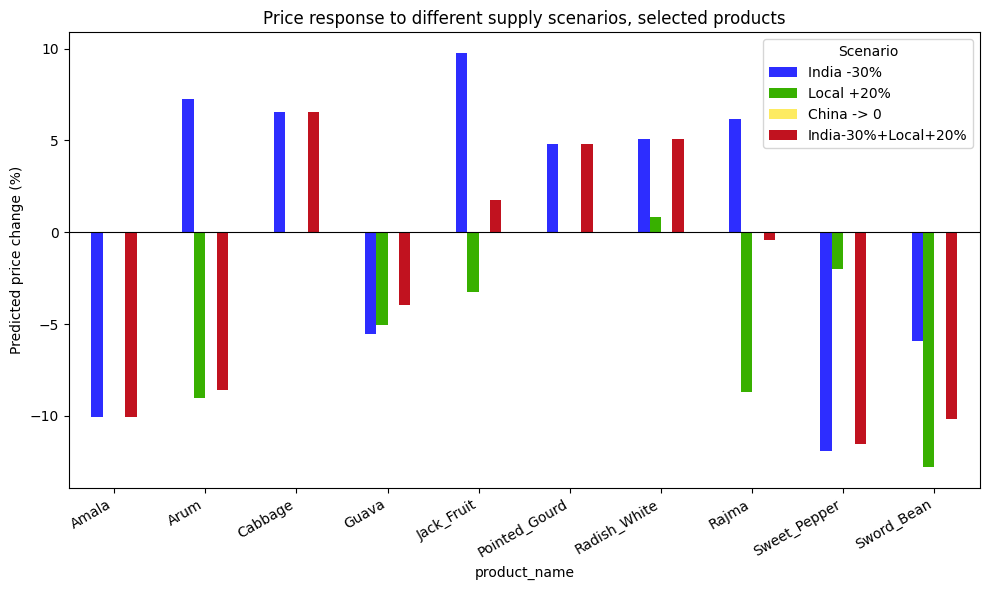

In [17]:

# pick top 10 products by absolute price sensitivity, using India as the reference scenario
ok_india = results_india[results_india['status']=='ok'].copy()
top10 = ok_india.reindex(ok_india['price_delta_pct'].abs().sort_values(ascending=False).index).head(10)
products_to_show = top10['product_name'].tolist()
print(products_to_show)
# products_to_show = ['Orange_Sweet', 'Apple', 'Pear', 'Jack_Fruit', 'Sweet_Pepper']

def get_deltas(df, products):
    ok = df[df['status']=='ok']
    return ok[ok['product_name'].isin(products)].set_index('product_name')['price_delta_pct']

comparison = pd.DataFrame({
    'India -30%': get_deltas(results_india, products_to_show),
    'Local +20%': get_deltas(results_local, products_to_show),
    'China -> 0': get_deltas(results_china, products_to_show),
    'India-30%+Local+20%': get_deltas(results_combined, products_to_show),
})

fig, ax = plt.subplots(figsize=(10,6))
comparison.plot(kind='bar', ax=ax, color=["#2d2dff","#38b000","#fdeb61",'#c1121f'])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Predicted price change (%)')
ax.set_title('Price response to different supply scenarios, selected products')
ax.legend(title='Scenario')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../outputs/images/scenario_shock_comparison_of_10_products.png', dpi=150)
plt.show()

Scenario Aggregate Comparision

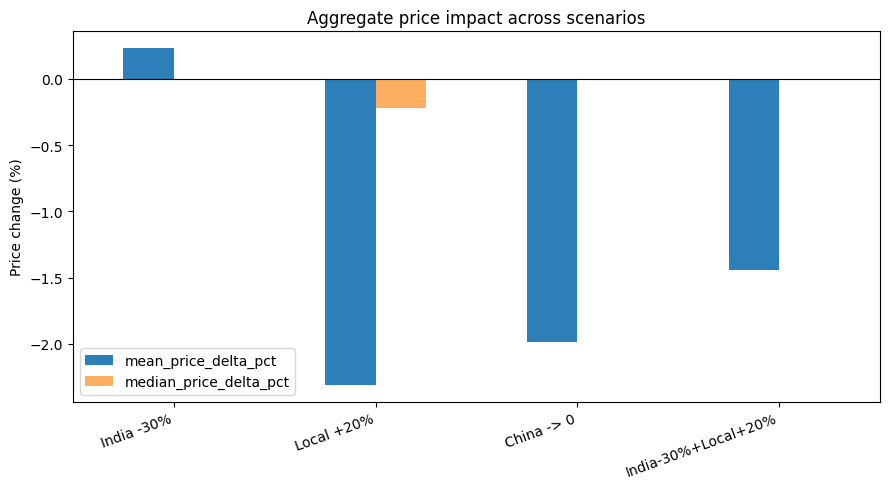

In [13]:
agg_compare = pd.DataFrame({
    'India -30%': summary_india,
    'Local +20%': summary_local,
    'China -> 0': summary_china,
    'India-30%+Local+20%': summary_combined,
}).T

fig, ax = plt.subplots(figsize=(9,5))
agg_compare[['mean_price_delta_pct','median_price_delta_pct']].plot(kind='bar', ax=ax, color=['#2c7fb8','#fdae61'])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Price change (%)')
ax.set_title('Aggregate price impact across scenarios')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../outputs/images/scenario_aggregate_comparison.png', dpi=150)
plt.show()